# Avance 2: Ingeniería de Características
## Proyecto Integrador - Equipo 32

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

En este segundo avance se implementa la ingeniería de características sobre el dataset de vacunación y casos de sarampión en México (2010-2023). Las transformaciones se fundamentan en los hallazgos del EDA (Avance 1), en particular: la naturaleza temporal de los datos, la ausencia de tendencia lineal, la presencia de estacionalidad en dosis, los resultados de la CCF (desfase temporal entre vacunación y casos), y la alta asimetría en ambas variables.

## 1. Configuración y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis

from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

print("Librerías cargadas")

Librerías cargadas


In [2]:
#usar solo si se está trabajando en Google Colab
#from google.colab import drive 
#drive.mount('/content/drive')

In [3]:
base_path = Path("..") / "data" / "processed"
print(f"Ruta base: {base_path}")
DATASET_FILE = base_path / "dataset_sarampion_vacunas_2010-2023.csv"
print(f"Ruta del dataset: {DATASET_FILE}")

df = pd.read_csv(DATASET_FILE)

print(f'Dataset: {df.shape[0]} registros, {df.shape[1]} columnas')
print(f'Período: {df["anio"].min()}-{df["anio"].max()}')
display(df.describe())

Ruta base: ../data/processed
Ruta del dataset: ../data/processed/dataset_sarampion_vacunas_2010-2023.csv
Dataset: 168 registros, 4 columnas
Período: 2010-2023


,mes,anio,total_dosis,casos_sarampion
count,168.000000,168.00000,1.680000e+02,168.000000
mean,6.500000,2016.50000,3.153230e+05,2.261905
std,3.462373,4.04318,3.567464e+05,11.132968
min,1.000000,2010.00000,1.115500e+04,0.000000
25%,3.750000,2013.00000,1.794778e+05,0.000000
50%,6.500000,2016.50000,2.292330e+05,0.000000
75%,9.250000,2020.00000,3.167408e+05,0.000000
max,12.000000,2023.00000,3.130610e+06,81.000000


El dataset base tiene 168 registros mensuales con 4 columnas: `anio`, `mes`, `total_dosis` y `casos_sarampion`. A partir de los hallazgos del EDA, crearemos características que capturen los patrones temporales identificados.

In [4]:
df["fecha"] = pd.to_datetime(df["anio"].astype(int).astype(str) + "-" + df["mes"].astype(int).astype(str) + "-01")
df = df.sort_values("fecha").reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())

Shape: (168, 5)


,mes,anio,total_dosis,casos_sarampion,fecha
0,1,2010,180830,0,2010-01-01
1,2,2010,183377,0,2010-02-01
2,3,2010,242572,0,2010-03-01
3,4,2010,216429,0,2010-04-01
4,5,2010,174559,0,2010-05-01


## 2. Generación de Nuevas Características

Las características se agrupan en categorías fundamentadas en el EDA:

| Categoría | Motivación (del EDA) |
|-----------|---------------------|
| Encoding cíclico del mes | El mes es cíclico (dic ≈ ene), no se debe usar en Pearson directamente |
| Medias móviles | La descomposición mostró tendencia no lineal; las ventanas capturan tendencias locales |
| Variables lag | La CCF reveló que la relación dosis→casos tiene desfase temporal |
| Tasas relativas | Dosis absolutas no reflejan cobertura; la tasa normaliza por escala |
| Agregados anuales | Los brotes se concentran en años específicos; el contexto anual es relevante |
| Interacción dosis×temporada | La estacionalidad en dosis interactúa con la temporada de transmisión |

Promedio de casos por mes (desc):


mes
7     6.071429
3     5.571429
4     5.428571
12    2.928571
5     2.285714
8     2.142857
10    1.214286
6     0.785714
11    0.428571
9     0.285714
1     0.000000
2     0.000000
Name: casos_sarampion, dtype: float64

Meses de temporada alta (TOP 5): [7, 3, 4, 12, 5]


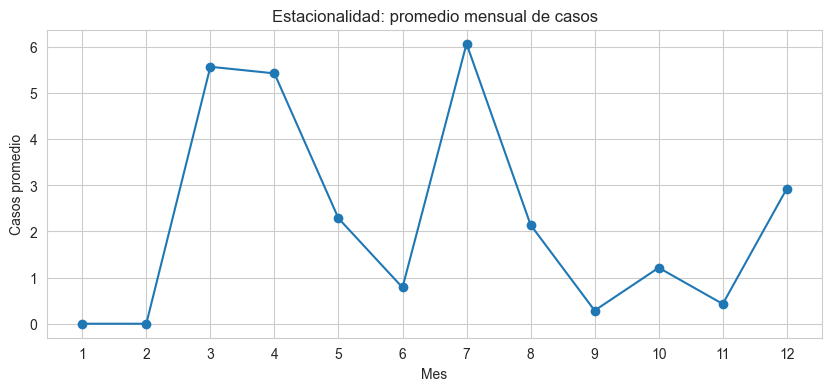

In [5]:
YEAR_MIN = 2010
YEAR_MAX = 2023
TOP_N_MESES = 5

df_season = df[(df["anio"] >= YEAR_MIN) & (df["anio"] <= YEAR_MAX)].copy()

seasonality = df_season.groupby("mes")["casos_sarampion"].mean().sort_values(ascending=False)
top_months = seasonality.head(TOP_N_MESES).index.tolist()

print("Promedio de casos por mes (desc):")
display(seasonality)

print(f"Meses de temporada alta (TOP {TOP_N_MESES}):", top_months)

plt.figure(figsize=(10,4))
seasonality.sort_index().plot(marker="o")
plt.title("Estacionalidad: promedio mensual de casos")
plt.xlabel("Mes")
plt.ylabel("Casos promedio")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

In [6]:
df_fe = df.copy()

# Encoding cíclico del mes
df_fe["mes_sin"] = np.sin(2 * np.pi * df_fe["mes"] / 12)
df_fe["mes_cos"] = np.cos(2 * np.pi * df_fe["mes"] / 12)

df_fe["anio_normalizado"] = (
    (df_fe["anio"] - df_fe["anio"].min()) /
    (df_fe["anio"].max() - df_fe["anio"].min())
)

# Medias móviles (ventanas 3 y 6)
for w in [3, 6]:
    df_fe[f"dosis_rolling_mean_{w}m"] = (
        df_fe["total_dosis"].shift(1).rolling(w, min_periods=w).mean()
    )
    df_fe[f"dosis_rolling_std_{w}m"] = (
        df_fe["total_dosis"].shift(1).rolling(w, min_periods=w).std()
    )
    df_fe[f"casos_rolling_mean_{w}m"] = (
        df_fe["casos_sarampion"].shift(1).rolling(w, min_periods=w).mean()
    )

# Lags 13 y 14
for lag in [13, 14]:
    df_fe[f"casos_lag_{lag}m"] = df_fe["casos_sarampion"].shift(lag)
    df_fe[f"dosis_lag_{lag}m"] = df_fe["total_dosis"].shift(lag)

# Derivadas entre lag13 y lag14
df_fe["dosis_lag13_minus_lag14"] = df_fe["dosis_lag_13m"] - df_fe["dosis_lag_14m"]
df_fe["dosis_lag13_div_lag14"] = df_fe["dosis_lag_13m"] / (df_fe["dosis_lag_14m"].replace(0, np.nan))

# Tasa relativa
df_fe["tasa_casos_por_millon_dosis"] = (
    df_fe["casos_sarampion"] /
    (df_fe["total_dosis"].replace(0, np.nan) / 1_000_000)
)

# Agregados anuales SIN fuga
df_fe["casos_ytd"] = df_fe.groupby("anio")["casos_sarampion"].transform(lambda s: s.shift(1).cumsum())
df_fe["dosis_ytd"] = df_fe.groupby("anio")["total_dosis"].transform(lambda s: s.shift(1).cumsum())

#Temporada alta
df_fe["temporada_alta"] = df_fe["mes"].isin(top_months).astype(int)
df_fe["dosis_x_temporada_alta"] = df_fe["total_dosis"] * df_fe["temporada_alta"]

df_fe = df_fe.replace([np.inf, -np.inf], np.nan)

nuevas = [c for c in df_fe.columns if c not in df.columns]
print(f"{len(nuevas)} características creadas:")
print(nuevas)
display(df_fe[nuevas].head(10))

20 características creadas:
['mes_sin', 'mes_cos', 'anio_normalizado', 'dosis_rolling_mean_3m', 'dosis_rolling_std_3m', 'casos_rolling_mean_3m', 'dosis_rolling_mean_6m', 'dosis_rolling_std_6m', 'casos_rolling_mean_6m', 'casos_lag_13m', 'dosis_lag_13m', 'casos_lag_14m', 'dosis_lag_14m', 'dosis_lag13_minus_lag14', 'dosis_lag13_div_lag14', 'tasa_casos_por_millon_dosis', 'casos_ytd', 'dosis_ytd', 'temporada_alta', 'dosis_x_temporada_alta']


,mes_sin,mes_cos,anio_normalizado,dosis_rolling_mean_3m,dosis_rolling_std_3m,casos_rolling_mean_3m,dosis_rolling_mean_6m,dosis_rolling_std_6m,casos_rolling_mean_6m,casos_lag_13m,dosis_lag_13m,casos_lag_14m,dosis_lag_14m,dosis_lag13_minus_lag14,dosis_lag13_div_lag14,tasa_casos_por_millon_dosis,casos_ytd,dosis_ytd,temporada_alta,dosis_x_temporada_alta
0,5.000000e-01,8.660254e-01,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0,0
1,8.660254e-01,5.000000e-01,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,180830.0,0,0
2,1.000000e+00,6.123234e-17,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,364207.0,1,242572
3,8.660254e-01,-5.000000e-01,0.0,202259.666667,34934.724363,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,606779.0,1,216429
4,5.000000e-01,-8.660254e-01,0.0,214126.000000,29664.623089,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,823208.0,1,174559
5,1.224647e-16,-1.000000e+00,0.0,211186.666667,34308.214561,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,997767.0,0,0
6,-5.000000e-01,-8.660254e-01,0.0,267344.333333,126197.010366,0.000000,234802.000000,90162.366358,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,352.961170,0.0,1408812.0,1,229487
7,-8.660254e-01,-5.000000e-01,0.0,271697.000000,123764.575400,27.000000,242911.500000,86448.770998,13.500000,NaN,NaN,NaN,NaN,NaN,NaN,98.155463,81.0,1638299.0,0,0
8,-1.000000e+00,-1.836970e-16,0.0,298410.000000,98355.889752,35.333333,254798.333333,81380.260613,17.666667,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,106.0,1892997.0,0,0
9,-8.660254e-01,5.000000e-01,0.0,230091.000000,24310.628067,35.333333,248717.666667,83803.461016,17.666667,NaN,NaN,NaN,NaN,NaN,NaN,37.856227,106.0,2099085.0,0,0


In [7]:
df_fe["casos_ytd"] = df_fe["casos_ytd"].fillna(0)
df_fe["dosis_ytd"] = df_fe["dosis_ytd"].fillna(0)

Se crearon 20 características derivadas. Notas sobre las decisiones:
- Se usan **lags de 13 y 14 meses**  porque con solo 168 registros, la CCF del EDA mostró las correlaciones más altas en esos 2 lags.
- No se crearon variables dummy de trimestre porque ya se cuenta con el encoding cíclico (sin/cos) que captura la misma información de forma continua.
- Los `fillna(0)` en lags de casos son apropiados dado que el valor natural antes del período observado es "sin casos conocidos".

## 3. Análisis de Distribuciones y Transformaciones

En el EDA se identificó que `total_dosis` (skewness ≈ 4.7) y `casos_sarampion` (skewness ≈ 5.9) tienen distribuciones muy sesgadas. Verificamos las distribuciones de las nuevas características y aplicamos transformaciones donde sea necesario.

In [8]:
num_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()

skew_vals = (
    df_fe[num_cols]
    .replace([np.inf, -np.inf], np.nan)
    .skew()
    .sort_values(ascending=False)
)

**Variables con mayor asimetría positiva**

In [9]:
display(skew_vals.head(15))

tasa_casos_por_millon_dosis    6.006311
casos_sarampion                5.950331
casos_lag_13m                  5.700647
casos_lag_14m                  5.680985
dosis_lag13_div_lag14          5.012193
total_dosis                    4.745481
casos_rolling_mean_3m          4.686875
dosis_lag_13m                  4.564160
dosis_lag_14m                  4.553964
dosis_x_temporada_alta         4.507725
dosis_rolling_std_3m           3.685327
dosis_rolling_mean_3m          3.632787
casos_ytd                      3.437044
casos_rolling_mean_6m          3.295246
dosis_rolling_std_6m           2.638682
dtype: float64

**Variables con mayor asimetría negativa**

In [10]:
display(skew_vals.tail(15))

dosis_x_temporada_alta     4.507725e+00
dosis_rolling_std_3m       3.685327e+00
dosis_rolling_mean_3m      3.632787e+00
casos_ytd                  3.437044e+00
casos_rolling_mean_6m      3.295246e+00
dosis_rolling_std_6m       2.638682e+00
dosis_rolling_mean_6m      2.496436e+00
dosis_lag13_minus_lag14    2.464830e+00
dosis_ytd                  2.007684e+00
temporada_alta             3.411150e-01
anio                       0.000000e+00
mes_sin                    0.000000e+00
anio_normalizado           0.000000e+00
mes                        0.000000e+00
mes_cos                   -2.565013e-16
dtype: float64


Variables con |skew| >= 1.0: 18
['tasa_casos_por_millon_dosis', 'casos_sarampion', 'casos_lag_13m', 'casos_lag_14m', 'dosis_lag13_div_lag14', 'total_dosis', 'casos_rolling_mean_3m', 'dosis_lag_13m', 'dosis_lag_14m', 'dosis_x_temporada_alta', 'dosis_rolling_std_3m', 'dosis_rolling_mean_3m', 'casos_ytd', 'casos_rolling_mean_6m', 'dosis_rolling_std_6m', 'dosis_rolling_mean_6m', 'dosis_lag13_minus_lag14', 'dosis_ytd']


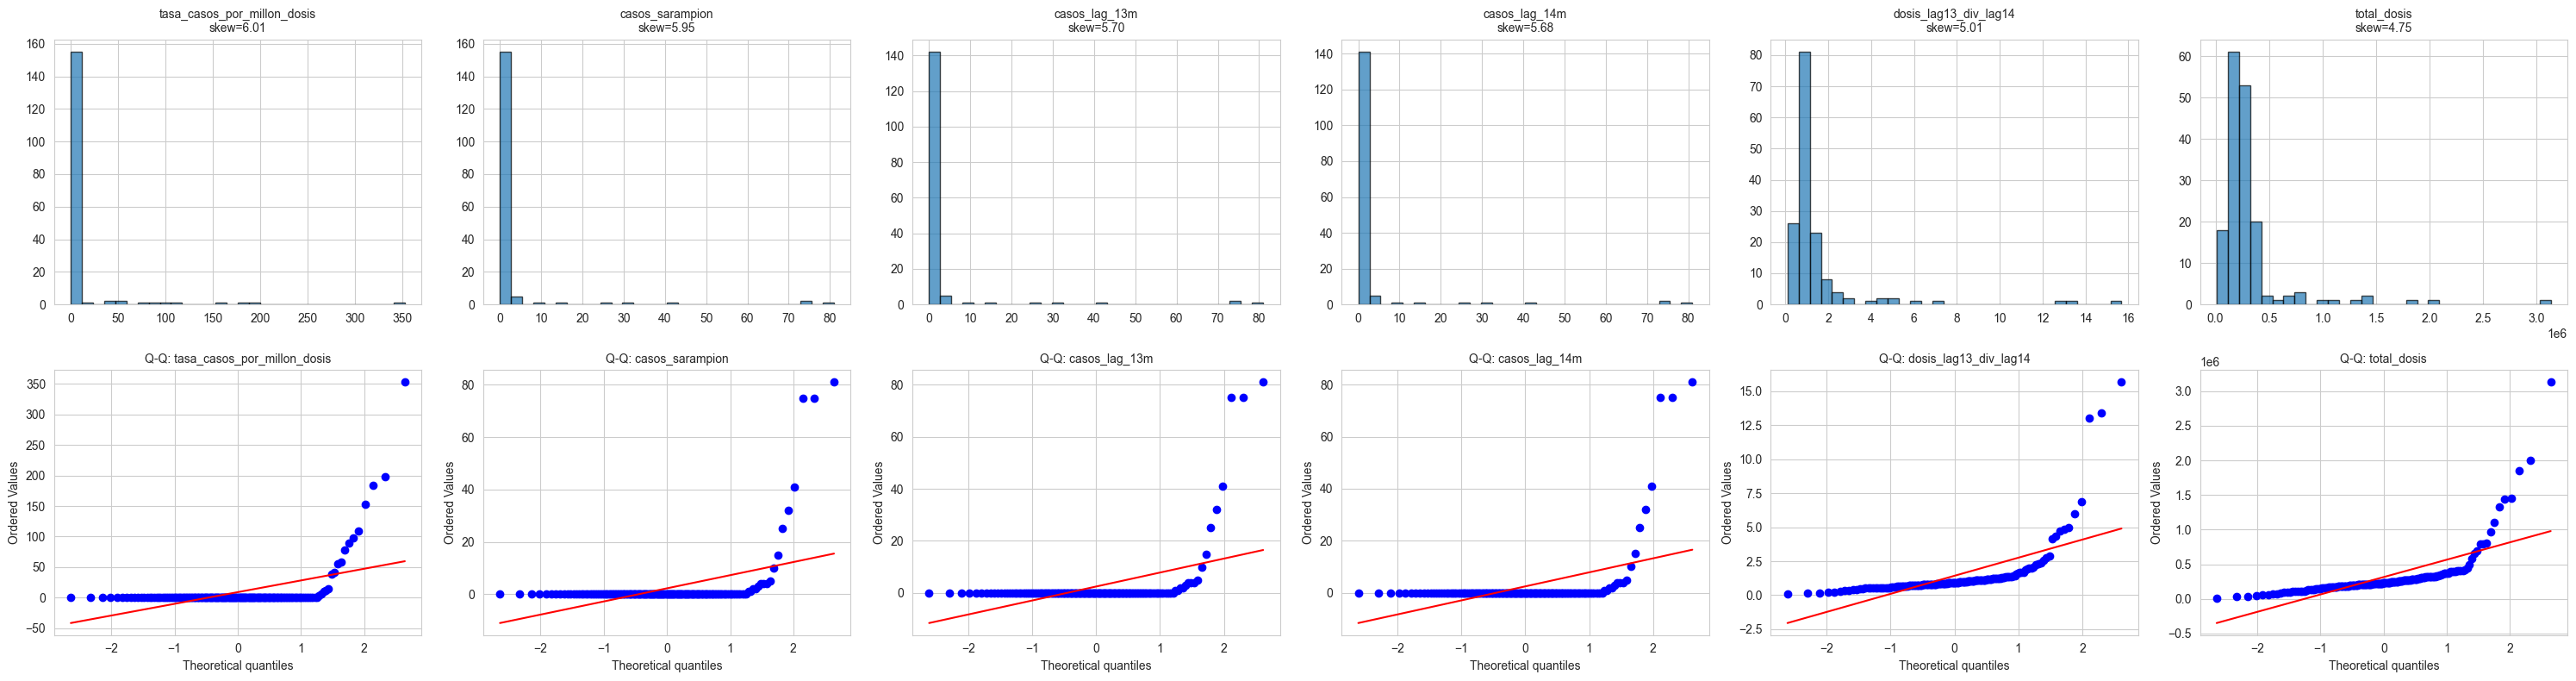

In [11]:
SKEW_THRESHOLD = 1.0
MAX_PLOTS = 6

vars_skewed = skew_vals[abs(skew_vals) >= SKEW_THRESHOLD].index.tolist()
print(f"\nVariables con |skew| >= {SKEW_THRESHOLD}: {len(vars_skewed)}")
print(vars_skewed[:25])

vars_plot = vars_skewed[:MAX_PLOTS]

if len(vars_plot) > 0:
    fig, axes = plt.subplots(2, len(vars_plot), figsize=(5 * len(vars_plot), 8))
    if len(vars_plot) == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i, var in enumerate(vars_plot):
        series = df_fe[var].replace([np.inf, -np.inf], np.nan).dropna()

        axes[0, i].hist(series, bins=30, edgecolor="black", alpha=0.7)
        axes[0, i].set_title(f"{var}\nskew={series.skew():.2f}", fontsize=10)

        stats.probplot(series, dist="norm", plot=axes[1, i])
        axes[1, i].set_title(f"Q-Q: {var}", fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No hay variables con alta asimetría según el umbral.")

Las variables de dosis y las derivadas de casos presentan sesgo positivo significativo, consistente con lo encontrado en el EDA. Los Q-Q plots confirman la desviación de normalidad especialmente en las colas.

In [12]:
df_t = df_fe.copy()

to_transform = skew_vals[abs(skew_vals) >= SKEW_THRESHOLD].index.tolist()

print(f"Variables candidatas a transformar (|skew| >= {SKEW_THRESHOLD}): {len(to_transform)}")
display(skew_vals.loc[to_transform].head(25))

created = []
for col in to_transform:
    s = df_t[col].replace([np.inf, -np.inf], np.nan)

    if s.dropna().min() >= 0:
        new_col = f"{col}_log"
        df_t[new_col] = np.log1p(s)
        created.append(new_col)

print(f"\nTransformaciones log1p creadas: {len(created)}")
print(created[:25])

Variables candidatas a transformar (|skew| >= 1.0): 18


tasa_casos_por_millon_dosis    6.006311
casos_sarampion                5.950331
casos_lag_13m                  5.700647
casos_lag_14m                  5.680985
dosis_lag13_div_lag14          5.012193
total_dosis                    4.745481
casos_rolling_mean_3m          4.686875
dosis_lag_13m                  4.564160
dosis_lag_14m                  4.553964
dosis_x_temporada_alta         4.507725
dosis_rolling_std_3m           3.685327
dosis_rolling_mean_3m          3.632787
casos_ytd                      3.437044
casos_rolling_mean_6m          3.295246
dosis_rolling_std_6m           2.638682
dosis_rolling_mean_6m          2.496436
dosis_lag13_minus_lag14        2.464830
dosis_ytd                      2.007684
dtype: float64


Transformaciones log1p creadas: 17
['tasa_casos_por_millon_dosis_log', 'casos_sarampion_log', 'casos_lag_13m_log', 'casos_lag_14m_log', 'dosis_lag13_div_lag14_log', 'total_dosis_log', 'casos_rolling_mean_3m_log', 'dosis_lag_13m_log', 'dosis_lag_14m_log', 'dosis_x_temporada_alta_log', 'dosis_rolling_std_3m_log', 'dosis_rolling_mean_3m_log', 'casos_ytd_log', 'casos_rolling_mean_6m_log', 'dosis_rolling_std_6m_log', 'dosis_rolling_mean_6m_log', 'dosis_ytd_log']


La transformación logarítmica reduce el sesgo de las variables de casos, aunque persiste cierta asimetría por la concentración de ceros (meses sin brotes). Esto es inherente a la naturaleza de los datos y no se puede eliminar completamente.

**Comparación de skewness**

In [13]:
for col_log in created[:15]:
    col = col_log.replace("_log", "")

    before = df_fe[col].replace([np.inf, -np.inf], np.nan).dropna().skew()
    after = df_t[col_log].replace([np.inf, -np.inf], np.nan).dropna().skew()

    print(f"{col:35s}  antes={before:7.2f}  después={after:7.2f}")


tasa_casos_por_millon_dosis          antes=   6.01  después=   3.10
casos_sarampion                      antes=   5.95  después=   3.80
casos_lag_13m                        antes=   5.70  después=   3.62
casos_lag_14m                        antes=   5.68  después=   3.61
dosis_lag13_div_lag14                antes=   5.01  después=   2.52
total_dosis                          antes=   4.75  después=   0.12
casos_rolling_mean_3m                antes=   4.69  después=   2.79
dosis_lag_13m                        antes=   4.56  después=   0.16
dosis_lag_14m                        antes=   4.55  después=   0.15
dosis_x_temporada_alta               antes=   4.51  después=   0.35
dosis_rolling_std_3m                 antes=   3.69  después=   0.50
dosis_rolling_mean_3m                antes=   3.63  después=   0.73
casos_ytd                            antes=   3.44  después=   2.49
casos_rolling_mean_6m                antes=   3.30  después=   2.07
dosis_rolling_std_6m                 antes=   2.

## 4. Escalamiento de Variables

Se aplica una única estrategia de escalamiento fundamentada en los hallazgos del EDA:

**RobustScaler** centra los datos usando la mediana y los escala usando el rango intercuartílico (IQR = Q3 − Q1), ambos estadísticos robustos ante valores atípicos. Esto es consistente con la decisión previa de usar transformaciones `log1p` para reducir asimetría: primero se reduce el sesgo y luego se escala de forma robusta.

**Decisiones adicionales:**
- **Eliminación de filas sin historia** (`dropna`): los NaN son estructurales (producidos por lags y rolling windows), no datos perdidos. Imputarlos con mediana violaría la causalidad temporal, por lo que se eliminan las filas iniciales donde no existe información previa suficiente.
- Se eliminan columnas con **varianza casi nula** (σ < 1e-8) que no aportan información discriminativa.

In [14]:
from sklearn.preprocessing import RobustScaler

target = "casos_sarampion"
id_cols = ["anio", "mes", "fecha"]

num_cols_t = df_t.select_dtypes(include=[np.number]).columns.tolist()
feat_cols = [c for c in num_cols_t if c not in [target, "anio", "mes"]]

df_s = df_t[id_cols + [target] + feat_cols].copy()

df_s = df_s.replace([np.inf, -np.inf], np.nan)

# Eliminar filas iniciales sin historia suficiente (NaN estructurales por lags/rolling)
df_s = df_s.dropna(subset=feat_cols).reset_index(drop=True)

stds = df_s[feat_cols].std()
feat_cols = [c for c in feat_cols if stds[c] > 1e-8]
df_s = df_s[id_cols + [target] + feat_cols].copy()

scaler = RobustScaler()
df_s[feat_cols] = scaler.fit_transform(df_s[feat_cols])

print("df_s listo:", df_s.shape)
print(f"Filas tras eliminar NaN estructurales: {df_s.shape[0]} (de 168 originales)")
display(df_s.head())

df_s listo: (154, 42)
Filas tras eliminar NaN estructurales: 154 (de 168 originales)


,anio,mes,fecha,casos_sarampion,total_dosis,mes_sin,mes_cos,anio_normalizado,dosis_rolling_mean_3m,dosis_rolling_std_3m,casos_rolling_mean_3m,dosis_rolling_mean_6m,dosis_rolling_std_6m,casos_rolling_mean_6m,casos_lag_13m,dosis_lag_13m,casos_lag_14m,dosis_lag_14m,dosis_lag13_minus_lag14,dosis_lag13_div_lag14,tasa_casos_por_millon_dosis,casos_ytd,dosis_ytd,temporada_alta,dosis_x_temporada_alta,tasa_casos_por_millon_dosis_log,casos_sarampion_log,casos_lag_13m_log,casos_lag_14m_log,dosis_lag13_div_lag14_log,total_dosis_log,casos_rolling_mean_3m_log,dosis_lag_13m_log,dosis_lag_14m_log,dosis_x_temporada_alta_log,dosis_rolling_std_3m_log,dosis_rolling_mean_3m_log,casos_ytd_log,casos_rolling_mean_6m_log,dosis_rolling_std_6m_log,dosis_rolling_mean_6m_log,dosis_ytd_log
0,2011,3,2011-03-01,0,1.661955,7.846097e-01,1.921739e-16,-1.0,0.816263,-0.099979,0.0,0.635018,-0.029576,3.166667,0.0,-0.293866,0.0,-0.315089,0.185856,0.203072,0.0,0.0,-0.394517,1.0,2.136469,0.0,0.0,0.0,0.0,0.202729,1.238637,0.0,-0.344933,-0.372922,1.061984,-0.111783,0.686942,0.0,1.427116,-0.045729,0.575164,-0.521968
1,2011,4,2011-04-01,0,0.729797,6.794919e-01,-3.923048e-01,-1.0,0.965808,0.157629,0.0,0.943175,-0.159130,3.166667,0.0,0.165461,0.0,-0.295233,0.680600,0.814894,0.0,0.0,-0.098764,1.0,1.535411,0.0,0.0,0.0,0.0,0.756401,0.651001,0.0,0.169054,-0.347066,1.035011,0.147760,0.791342,0.0,1.427116,-0.293973,0.805945,-0.102257
2,2011,5,2011-05-01,0,-0.263499,3.923048e-01,-6.794919e-01,-1.0,1.074907,-0.041438,0.0,0.845165,-0.135996,0.666667,0.0,-0.037397,0.0,0.166231,-0.064712,-0.038429,0.0,0.0,0.113784,1.0,0.894931,0.0,0.0,0.0,0.0,-0.039577,-0.309203,0.0,-0.040462,0.170100,0.990936,-0.044292,0.864312,0.0,0.510826,-0.242333,0.735270,0.103611
3,2011,6,2011-06-01,0,0.960134,2.882609e-16,-7.846097e-01,-1.0,0.577159,0.656086,0.0,0.557221,0.022082,0.000000,0.0,-0.362289,0.0,-0.037571,-0.202066,-0.208238,0.0,0.0,0.237671,0.0,0.000000,0.0,0.0,0.0,0.0,-0.219486,0.815245,0.0,-0.435477,-0.040712,0.000000,0.482502,0.508229,0.0,0.000000,0.032216,0.512639,0.202989
4,2011,7,2011-07-01,0,0.907595,-3.923048e-01,-6.794919e-01,-1.0,0.314723,0.211915,0.0,0.504966,0.001874,0.000000,0.0,1.472735,0.0,-0.363975,2.228996,2.860032,0.0,0.0,0.470779,1.0,1.650056,0.0,0.0,0.0,0.0,2.183596,0.779094,0.0,1.138046,-0.438169,1.040890,0.192497,0.292474,0.0,0.000000,0.002797,0.469566,0.361963


## 5. Selección de Características
Los métodos clásicos de filtrado (Pearson, ANOVA, MI) asumen observaciones i.i.d., lo cual no aplica en series temporales donde existe autocorrelación. Por ello usamos métodos que respetan la estructura temporal:

1. **Eliminación por multicolinealidad** entre features (|r| > 0.90) — válido porque compara features entre sí, no contra el target
2. **LassoCV con TimeSeriesSplit** — regularización L1 con validación cruzada que respeta el orden cronológico (nunca usa datos futuros para validar)
3. **Granger Causality** — test formal de si los valores pasados de una feature mejoran la predicción de `casos_sarampion`

In [15]:
GRANGER_MAX_LAG = 24 #lag
MIN_FEATURES = 10 #Min Características
CORR_THRESHOLD = 0.90
ALPHA_GRANGER = 0.05

X_cols = [c for c in df_s.columns if c not in ["anio", "mes", "fecha", target]]
X = df_s[X_cols].copy()
y = df_s[target].copy()

print("Features candidatas iniciales:", X.shape[1])

Features candidatas iniciales: 38


**Eliminar variables por colinearidad**

In [16]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_with_y = X.apply(lambda s: np.corrcoef(s, y)[0, 1]).abs()
corr_with_y = corr_with_y.replace([np.inf, -np.inf], np.nan).fillna(0)

to_drop = set()
for col in upper.columns:
    rows = upper.index[upper[col] > CORR_THRESHOLD].tolist()
    for row in rows:
        drop = row if corr_with_y[row] < corr_with_y[col] else col
        to_drop.add(drop)

X_mc = X.drop(columns=list(to_drop), errors="ignore")
print("Tras multicolinealidad:", X_mc.shape[1], "| eliminadas:", len(to_drop))

Tras multicolinealidad: 31 | eliminadas: 7


**Método de Lasso Time Series Split**

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

lasso = LassoCV(
    cv=tscv,
    random_state=42,
    n_alphas=200,
    max_iter=20000
)
lasso.fit(X_mc, y)

coef = pd.Series(lasso.coef_, index=X_mc.columns)
lasso_selected = coef[coef.abs() > 1e-8].sort_values(key=np.abs, ascending=False)

print("Lasso seleccionó:", len(lasso_selected))
display(lasso_selected.head(25))

Lasso seleccionó: 25


casos_sarampion_log           12.450949
dosis_rolling_mean_3m_log      1.543864
total_dosis_log                1.521864
casos_rolling_mean_6m_log      1.133207
dosis_lag_14m_log              1.028320
dosis_x_temporada_alta         0.958840
casos_lag_13m_log              0.945812
dosis_rolling_mean_3m         -0.827790
anio_normalizado               0.793295
dosis_x_temporada_alta_log    -0.560831
dosis_rolling_std_6m_log       0.482752
dosis_ytd                     -0.400907
dosis_lag_13m_log              0.384795
total_dosis                   -0.286498
casos_rolling_mean_3m         -0.245707
dosis_lag_13m                 -0.231374
dosis_lag_14m                 -0.151908
dosis_rolling_std_3m_log       0.141856
casos_lag_13m                 -0.134207
dosis_rolling_std_3m           0.082728
dosis_lag13_div_lag14          0.072493
casos_lag_14m                 -0.038718
mes_sin                       -0.036410
casos_ytd_log                 -0.031220
dosis_ytd_log                 -0.023686


**Método Granger**

In [18]:
def granger_pmin(feature: str, df_local: pd.DataFrame, max_lag: int) -> float:
    tmp = df_local[[target, feature]].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) < (max_lag + 8):
        return 1.0

    tmp = tmp.diff().dropna()
    if len(tmp) < (max_lag + 8):
        return 1.0

    try:
        res = grangercausalitytests(tmp, maxlag=max_lag, verbose=False)
        pvals = [res[i + 1][0]["ssr_chi2test"][1] for i in range(max_lag)]
        return float(np.nanmin(pvals))
    except Exception:
        return 1.0

df_g = df_s[[target] + list(X_mc.columns)].copy()

granger_scores = {f: granger_pmin(f, df_g, GRANGER_MAX_LAG) for f in X_mc.columns}
granger_p = pd.Series(granger_scores).sort_values()
granger_selected = granger_p[granger_p <= ALPHA_GRANGER]

print(f"Granger (p<={ALPHA_GRANGER}) seleccionó:", len(granger_selected))
display(granger_selected.head(25))

Granger (p<=0.05) seleccionó: 14


casos_sarampion_log          3.999059e-15
casos_ytd_log                2.541493e-09
casos_rolling_mean_3m        1.231357e-05
casos_rolling_mean_3m_log    1.931578e-05
dosis_lag_14m_log            9.900567e-05
dosis_lag_13m_log            2.014057e-04
casos_rolling_mean_6m_log    5.009244e-04
dosis_rolling_mean_3m_log    6.105610e-04
total_dosis_log              7.589499e-04
dosis_rolling_std_3m_log     3.991876e-03
casos_lag_13m_log            1.695350e-02
casos_lag_14m_log            1.713758e-02
anio_normalizado             4.053027e-02
dosis_rolling_std_6m_log     4.127084e-02
dtype: float64

**Unión Granger-Lasso**

In [19]:
selected = set(lasso_selected.index).union(set(granger_selected.index))

if len(selected) < MIN_FEATURES:
    combo = pd.DataFrame({
        "g_rank": granger_p.rank(),
        "l_rank": coef.abs().reindex(X_mc.columns).fillna(0).rank(ascending=False)
    })
    combo["score"] = combo["g_rank"] + combo["l_rank"]
    combo = combo.sort_values("score")

    for f in combo.index:
        selected.add(f)
        if len(selected) >= MIN_FEATURES:
            break

features_union = list(selected)

resumen = pd.DataFrame({
    "feature": features_union,
    "granger_pmin": [granger_scores.get(f, 1.0) for f in features_union],
    "lasso_coef": [coef.get(f, 0.0) for f in features_union],
    "abs_lasso": [abs(coef.get(f, 0.0)) for f in features_union],
}).sort_values(["granger_pmin", "abs_lasso"], ascending=[True, False])

print("Features (unión):", len(features_union))
display(resumen.head(40))

Features (unión): 27


,feature,granger_pmin,lasso_coef,abs_lasso
2,casos_sarampion_log,3.999059e-15,12.450949,12.450949
4,casos_ytd_log,2.541493e-09,-0.031220,0.031220
7,casos_rolling_mean_3m,1.231357e-05,-0.245707,0.245707
24,casos_rolling_mean_3m_log,1.931578e-05,0.000000,0.000000
3,dosis_lag_14m_log,9.900567e-05,1.028320,1.028320
9,dosis_lag_13m_log,2.014057e-04,0.384795,0.384795
18,casos_rolling_mean_6m_log,5.009244e-04,1.133207,1.133207
23,dosis_rolling_mean_3m_log,6.105610e-04,1.543864,1.543864
21,total_dosis_log,7.589499e-04,1.521864,1.521864
1,dosis_rolling_std_3m_log,3.991876e-03,0.141856,0.141856


**Selección de Características**

In [20]:
MAX_FEATURES = 12       #Max Seleccionar
P_THRESHOLD = 0.001
LASSO_THRESHOLD = 0.05

final_df = resumen.copy()

def root_name(f: str) -> str:
    return f.replace("_log", "")

# 1) Quitar duplicados original vs _log (quedarse con el mejor)
final_df["root"] = final_df["feature"].apply(root_name)
final_df = final_df.sort_values(["granger_pmin", "abs_lasso"], ascending=[True, False])
final_df = final_df.groupby("root", as_index=False).head(1)

# 2) Filtro de importancia
filtered = final_df[
    (final_df["granger_pmin"] < P_THRESHOLD) |
    (final_df["abs_lasso"] > LASSO_THRESHOLD)
].copy()

# Si quedó demasiado estricto, usar ranking sin filtro
if filtered.shape[0] < MAX_FEATURES:
    filtered = final_df.copy()

# 3) Forzar máximo
filtered = filtered.sort_values(["granger_pmin", "abs_lasso"], ascending=[True, False]).head(MAX_FEATURES)

features_final = filtered["feature"].tolist()

print("Features finales reducidas:", len(features_final))
print(features_final)
display(filtered)


Features finales reducidas: 12
['casos_sarampion_log', 'casos_ytd_log', 'casos_rolling_mean_3m', 'dosis_lag_14m_log', 'dosis_lag_13m_log', 'casos_rolling_mean_6m_log', 'dosis_rolling_mean_3m_log', 'total_dosis_log', 'dosis_rolling_std_3m_log', 'casos_lag_13m_log', 'anio_normalizado', 'dosis_rolling_std_6m_log']


,feature,granger_pmin,lasso_coef,abs_lasso,root
2,casos_sarampion_log,3.999059e-15,12.450949,12.450949,casos_sarampion
4,casos_ytd_log,2.541493e-09,-0.031220,0.031220,casos_ytd
7,casos_rolling_mean_3m,1.231357e-05,-0.245707,0.245707,casos_rolling_mean_3m
3,dosis_lag_14m_log,9.900567e-05,1.028320,1.028320,dosis_lag_14m
9,dosis_lag_13m_log,2.014057e-04,0.384795,0.384795,dosis_lag_13m
18,casos_rolling_mean_6m_log,5.009244e-04,1.133207,1.133207,casos_rolling_mean_6m
23,dosis_rolling_mean_3m_log,6.105610e-04,1.543864,1.543864,dosis_rolling_mean_3m
21,total_dosis_log,7.589499e-04,1.521864,1.521864,total_dosis
1,dosis_rolling_std_3m_log,3.991876e-03,0.141856,0.141856,dosis_rolling_std_3m
25,casos_lag_13m_log,1.695350e-02,0.945812,0.945812,casos_lag_13m


La selección se realizó con métodos apropiados para series temporales:

- **Multicolinealidad**: Se eliminaron features redundantes (|r| > 0.90 entre sí), conservando la más correlacionada con el target.
- **LassoCV + TimeSeriesSplit**: La regularización L1 fuerza coeficientes a cero, y la validación temporal garantiza que no se usa información futura. El valor de α fue seleccionado automáticamente por CV.
- **Granger Causality**: Identifica features cuyos valores pasados aportan poder predictivo sobre `casos_sarampion`, lo cual es la pregunta correcta en un contexto temporal.

Las features presentes en ambos métodos (Lasso ∩ Granger) son las más robustas. Las presentes en solo uno se incluyen pero deben interpretarse con cautela.

## 6. Extracción de Características (PCA y Factor Analysis)

Reducimos dimensionalidad sobre las características seleccionadas. Con PCA buscamos los componentes que expliquen ≥95% de la varianza; con Factor Analysis buscamos factores latentes interpretables.

**Nota sobre estandarización:** Se aplica `StandardScaler` (media=0, σ=1) como preprocesamiento local antes de PCA y Factor Analysis. Esto es necesario porque PCA maximiza varianza y requiere que todas las features contribuyan con varianza uniforme. El `RobustScaler` de la sección 4 protege contra outliers pero no garantiza σ=1; sin esta estandarización adicional, un solo componente/factor absorbe casi toda la varianza. Ambos escaladores cumplen funciones distintas y complementarias: RobustScaler para el pipeline general, StandardScaler específicamente para la descomposición de varianza.

Componentes para 95% varianza: 10
Componentes seleccionados: 10
Varianza explicada total (PCA): 96.76%


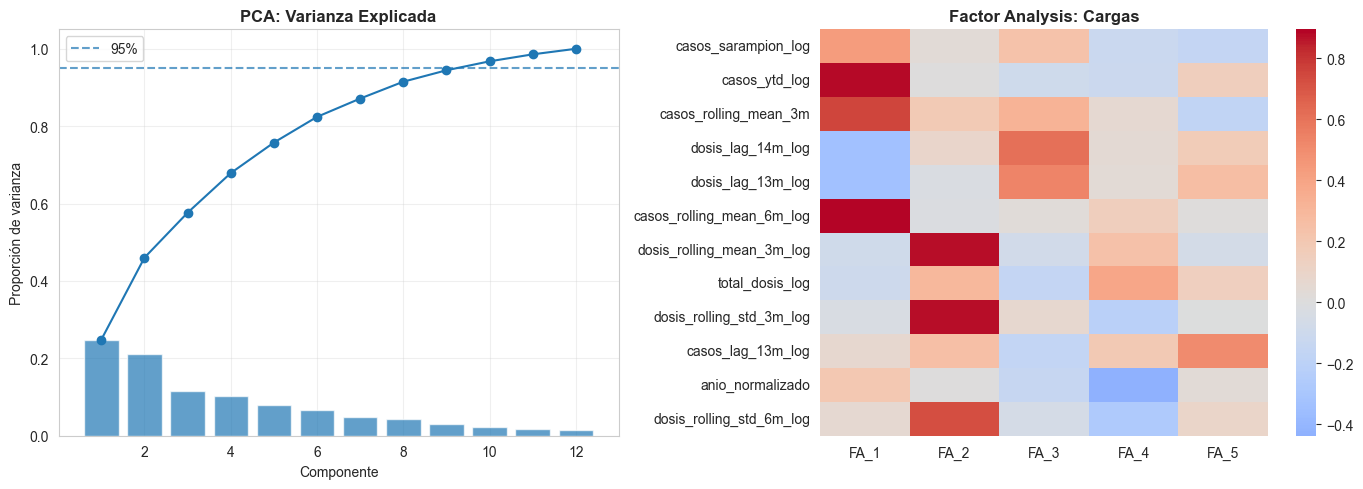


Top 10 cargas factoriales (por magnitud máxima):


,FA_1,FA_2,FA_3,FA_4,FA_5
casos_rolling_mean_6m_log,0.895344,-0.021299,0.026415,0.151511,0.014581
casos_ytd_log,0.880030,0.009577,-0.092106,-0.112008,0.148930
dosis_rolling_std_3m_log,-0.028744,0.873796,0.072339,-0.209609,-0.000956
dosis_rolling_mean_3m_log,-0.084304,0.869383,-0.081207,0.241991,-0.067842
casos_rolling_mean_3m,0.756251,0.185861,0.325275,0.058900,-0.170099
dosis_rolling_std_6m_log,0.060978,0.730581,-0.058972,-0.270340,0.097597
dosis_lag_14m_log,-0.338347,0.083828,0.612980,0.046304,0.175958
dosis_lag_13m_log,-0.338154,-0.023407,0.533797,0.036645,0.260602
casos_lag_13m_log,0.069658,0.250875,-0.157993,0.196957,0.506613
casos_sarampion_log,0.439609,0.035869,0.228894,-0.123333,-0.154148



df_pca shape: (154, 10)
df_fa shape: (154, 5)


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis

X_sel = df_s[features_final].copy()

X_sel = X_sel.replace([np.inf, -np.inf], np.nan).dropna()

# StandardScaler antes de PCA/FA: necesario porque PCA maximiza varianza
# y requiere features con varianza uniforme (σ=1). RobustScaler (sección 4)
# no garantiza σ=1, por lo que sin esta estandarización un solo componente
# captura casi toda la varianza. Este StandardScaler es un preprocesamiento
# local específico para PCA/FA, no reemplaza al RobustScaler del pipeline general.
sc = StandardScaler()
X_std = sc.fit_transform(X_sel)

pca_full = PCA(random_state=42).fit(X_std)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

n95 = int(np.argmax(var_acum >= 0.95) + 1)

MAX_PCA = min(12, X_std.shape[1])     #Número de features
MIN_PCA = 3
n_comp = max(MIN_PCA, min(n95, MAX_PCA))

print(f"Componentes para 95% varianza: {n95}")
print(f"Componentes seleccionados: {n_comp}")

pca = PCA(n_components=n_comp, random_state=42).fit(X_std)
df_pca = pd.DataFrame(
    pca.transform(X_std),
    index=X_sel.index,
    columns=[f"PCA_{i+1}" for i in range(n_comp)]
)

print(f"Varianza explicada total (PCA): {pca.explained_variance_ratio_.sum():.2%}")

n_fa = min(5, X_std.shape[1])
fa = FactorAnalysis(n_components=n_fa, random_state=42).fit(X_std)

df_fa = pd.DataFrame(
    fa.transform(X_std),
    index=X_sel.index,
    columns=[f"FA_{i+1}" for i in range(n_fa)]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    range(1, len(pca_full.explained_variance_ratio_) + 1),
    pca_full.explained_variance_ratio_,
    alpha=0.7
)
axes[0].plot(range(1, len(var_acum) + 1), var_acum, "o-")
axes[0].axhline(0.95, linestyle="--", alpha=0.7, label="95%")
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("Proporción de varianza")
axes[0].set_title("PCA: Varianza Explicada", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

loadings = pd.DataFrame(
    fa.components_.T,
    index=features_final,
    columns=[f"FA_{i+1}" for i in range(n_fa)]
)

sns.heatmap(loadings, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Factor Analysis: Cargas", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nTop 10 cargas factoriales (por magnitud máxima):")
top = loadings.loc[loadings.abs().max(axis=1).sort_values(ascending=False).index].head(10)
display(top)

print("\ndf_pca shape:", df_pca.shape)
print("df_fa shape:", df_fa.shape)

**Interpretación de los resultados:**

**PCA:** El primer componente captura la mayor parte de la varianza, lo cual refleja la alta correlación entre las características seleccionadas (variables de casos, lags y medias móviles están naturalmente correlacionadas). El criterio de 95% de varianza acumulada define el número de componentes, con un mínimo de 3 para preservar diversidad de información.

**Factor Analysis — Interpretación de factores latentes:**

| Factor | Cargas dominantes | Interpretación |
|--------|-------------------|----------------|
| **FA_1** | `casos_rolling_mean_6m_log` (0.90), `casos_ytd_log` (0.88), `casos_rolling_mean_3m` (0.76) | **Incidencia actual de brotes**: captura el nivel reciente y acumulado de casos de sarampión |
| **FA_2** | `dosis_rolling_std_3m_log` (0.87), `dosis_rolling_mean_3m_log` (0.87), `dosis_rolling_std_6m_log` (0.73) | **Actividad de vacunación reciente**: refleja tanto el nivel como la variabilidad de las dosis aplicadas en meses recientes |
| **FA_3** | `dosis_lag_14m_log` (0.61), `dosis_lag_13m_log` (0.53) | **Vacunación histórica (13-14 meses atrás)**: captura el efecto diferido de la vacunación, consistente con el desfase identificado en la CCF del EDA |
| **FA_4** | Sin carga dominante clara; cargas moderadas opuestas en variabilidad vs. nivel de dosis | **Contraste dosis-variabilidad**: factor residual de difícil interpretación, posible artefacto del número de factores elegido |
| **FA_5** | `casos_lag_13m_log` (0.51) | **Casos históricos**: captura la incidencia de sarampión de hace ~1 año, complementando FA_1 (actual) con la perspectiva histórica |

Los tres primeros factores son los más interpretables y relevantes: separan claramente la **dinámica de casos** (FA_1), la **actividad vacunal reciente** (FA_2) y el **efecto diferido de vacunación** (FA_3). Esta separación confirma que las features seleccionadas capturan dimensiones distintas del fenómeno epidemiológico.

## 7. Dataset Final

In [22]:
common_index = df_s.index
if "df_pca" in globals():
    common_index = common_index.intersection(df_pca.index)
if "df_fa" in globals():
    common_index = common_index.intersection(df_fa.index)

base_cols = ["fecha", "anio", "mes", "casos_sarampion"]
df_base = df_s.loc[common_index, base_cols].copy()
df_feats = df_s.loc[common_index, features_final].copy()

parts = [df_base, df_feats]

if "df_pca" in globals():
    parts.append(df_pca.loc[common_index].copy())

if "df_fa" in globals():
    parts.append(df_fa.loc[common_index].copy())

df_final = pd.concat(parts, axis=1)

print(f"Dataset final: {df_final.shape}")
print(f"Valores faltantes: {df_final.isna().sum().sum()}")
display(df_final.head())


Dataset final: (154, 31)
Valores faltantes: 0


,fecha,anio,mes,casos_sarampion,casos_sarampion_log,casos_ytd_log,casos_rolling_mean_3m,dosis_lag_14m_log,dosis_lag_13m_log,casos_rolling_mean_6m_log,dosis_rolling_mean_3m_log,total_dosis_log,dosis_rolling_std_3m_log,casos_lag_13m_log,anio_normalizado,dosis_rolling_std_6m_log,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,FA_1,FA_2,FA_3,FA_4,FA_5
0,2011-03-01,2011,3,0,0.0,0.0,0.0,-0.372922,-0.344933,1.427116,0.686942,1.238637,-0.111783,0.0,-1.0,-0.045729,0.066636,0.023213,-0.382270,1.557465,-1.528589,-0.420780,-0.340449,-0.006451,0.307705,-0.180429,0.294099,0.051748,-0.296501,1.516372,-0.379881
1,2011-04-01,2011,4,0,0.0,0.0,0.0,-0.347066,0.169054,1.427116,0.791342,0.651001,0.147760,0.0,-1.0,-0.293973,-0.045249,-0.061180,-0.032263,1.407906,-1.477658,-0.620103,-0.249111,0.157859,-0.214517,-0.446380,0.267235,0.135894,-0.081996,1.447173,-0.394989
2,2011-05-01,2011,5,0,0.0,0.0,0.0,0.170100,-0.040462,0.510826,0.864312,-0.309203,-0.044292,0.0,-1.0,-0.242333,-0.623868,-0.206700,0.145726,0.771165,-1.391200,-0.844666,0.310061,-0.096994,-0.337061,-0.210999,-0.181440,0.073379,-0.011486,1.028129,-0.487531
3,2011-06-01,2011,6,0,0.0,0.0,0.0,-0.040712,-0.435477,0.000000,0.508229,0.815245,0.482502,0.0,-1.0,0.032216,-0.771702,0.448028,-0.272376,0.764829,-1.485083,-0.253500,0.249152,-0.082761,0.089733,-0.214491,-0.406183,0.307407,-0.167644,0.431292,-0.414192
4,2011-07-01,2011,7,0,0.0,0.0,0.0,-0.438169,1.138046,0.000000,0.292474,0.779094,0.192497,0.0,-1.0,0.002797,-1.041097,0.148171,0.174564,1.013160,-1.161382,-0.042865,0.044325,0.867949,-0.160251,-0.043683,-0.437270,0.066624,0.084532,0.510480,-0.146270


In [23]:
output_path = Path("..") / "data" / "processed" / "dataset_sarampion_features_engineered.csv"
df_final.to_csv(output_path, index=False)
print(f"\nGuardado en: {output_path}")


Guardado en: ../data/processed/dataset_sarampion_features_engineered.csv


## 8. Conclusiones

### Resumen de lo realizado

Se partió del dataset base de 4 columnas (serie de tiempo mensual) y se construyó un dataset de modelado con las siguientes transformaciones:

1. **20 características nuevas** fundamentadas en hallazgos del EDA: encoding cíclico del mes, medias móviles de 3 y 6 meses, lags de 13-14 meses (motivados por la CCF), tasas relativas, agregados anuales (YTD) e interacción dosis×temporada.

2. **Transformaciones de distribución**: log(x+1) para variables con alta asimetría, reduciendo el sesgo identificado en el EDA (skewness de 4.7 y 5.9 respectivamente).

3. **Escalamiento aplicado**: eliminación de filas sin historia suficiente (NaN estructurales por lags/rolling, no datos perdidos) y escalamiento con **RobustScaler** (mediana + IQR), elegido por su resistencia a los outliers extremos identificados en el EDA; además, se eliminaron columnas con varianza casi nula.

4. **Selección temporal**: Eliminación de multicolinealidad + LassoCV con TimeSeriesSplit + Granger Causality. Se usaron métodos que respetan el orden cronológico y la dependencia temporal del dataset, a diferencia de filtros i.i.d. (Pearson, ANOVA, MI) que asumen independencia entre observaciones.

5. **Reducción dimensional**: PCA y Factor Analysis con estandarización local previa (`StandardScaler`) para garantizar varianza uniforme entre features, necesaria porque PCA maximiza varianza. Se retiene el número de componentes que explica ≥95% de la varianza (con mínimo de 3), y Factor Analysis con hasta 5 factores para interpretar estructura latente.

### Limitaciones
- El dataset es pequeño (154 registros), lo que limita la complejidad de los modelos que se pueden entrenar sin sobreajuste.
- No se cuenta con datos de **cobertura de vacunación** (% de población meta vacunada), que sería más informativo que dosis absolutas.
- Los datos llegan hasta 2023; la incorporación de 2024-2025 enriquecería el análisis.

### Siguiente paso
El dataset `dataset_sarampion_features_engineered.csv` está listo para la fase de modelado, donde se aplicará particionamiento temporal (train/test respetando orden cronológico) y se evaluarán modelos de series de tiempo y clasificación para predicción de brotes.